In [25]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(data.table)
library(ggplot2)
library(ggrepel)
library(stringr)
devtools::load_all('utils/modules/R/gwastools')

i Loading gwastools

Warning message in setup_ns_exports(path, export_all, export_imports):
"Objects listed as exports, but not present in namespace: summarize_bcftools_trio_stats"


# Simulating absence of effect

In [32]:
files <- list.files('data/simulation/saige/step2', pattern = ".txt$", full.names = TRUE)

In [35]:
files <- files[grepl("ukb_eur_h2_0.00_0.00_0.00_pi_0.00_0.00_0.00_K0.1_aNA_bNA_tNA_chr21", files)]
print(length(files))
#files <- "data/simulation/saige/step2/ukb_eur_h2_0.0_0.1_pi_0.0_0.1_K_0.1_chr21_y_cts_8_pLoF_damaging_missense.txt"

[1] 32


In [44]:
ribbon_p <- 0.95
d <- do.call(rbind, lapply(files, function(f){
    d <- fread(f)
    if (nrow(d) > 0){
        d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
        n <- length(d$p.value)
        dt <- data.table(
            ensembl_gene_id = d$MarkerID[order(d$p.value)],
            pvalue.observed = -log10(sort(d$p.value)),
            pvalue.expected = -log10(sort(d$p.value.expt)),
            clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
            cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
            seed = gsub('cts_','',str_extract(f, "cts_[0-9]+")),
            parameters = str_extract(f, "h2_.+chr21")
        )
    return(dt)
    } else {
        return(NULL)
    }
}))

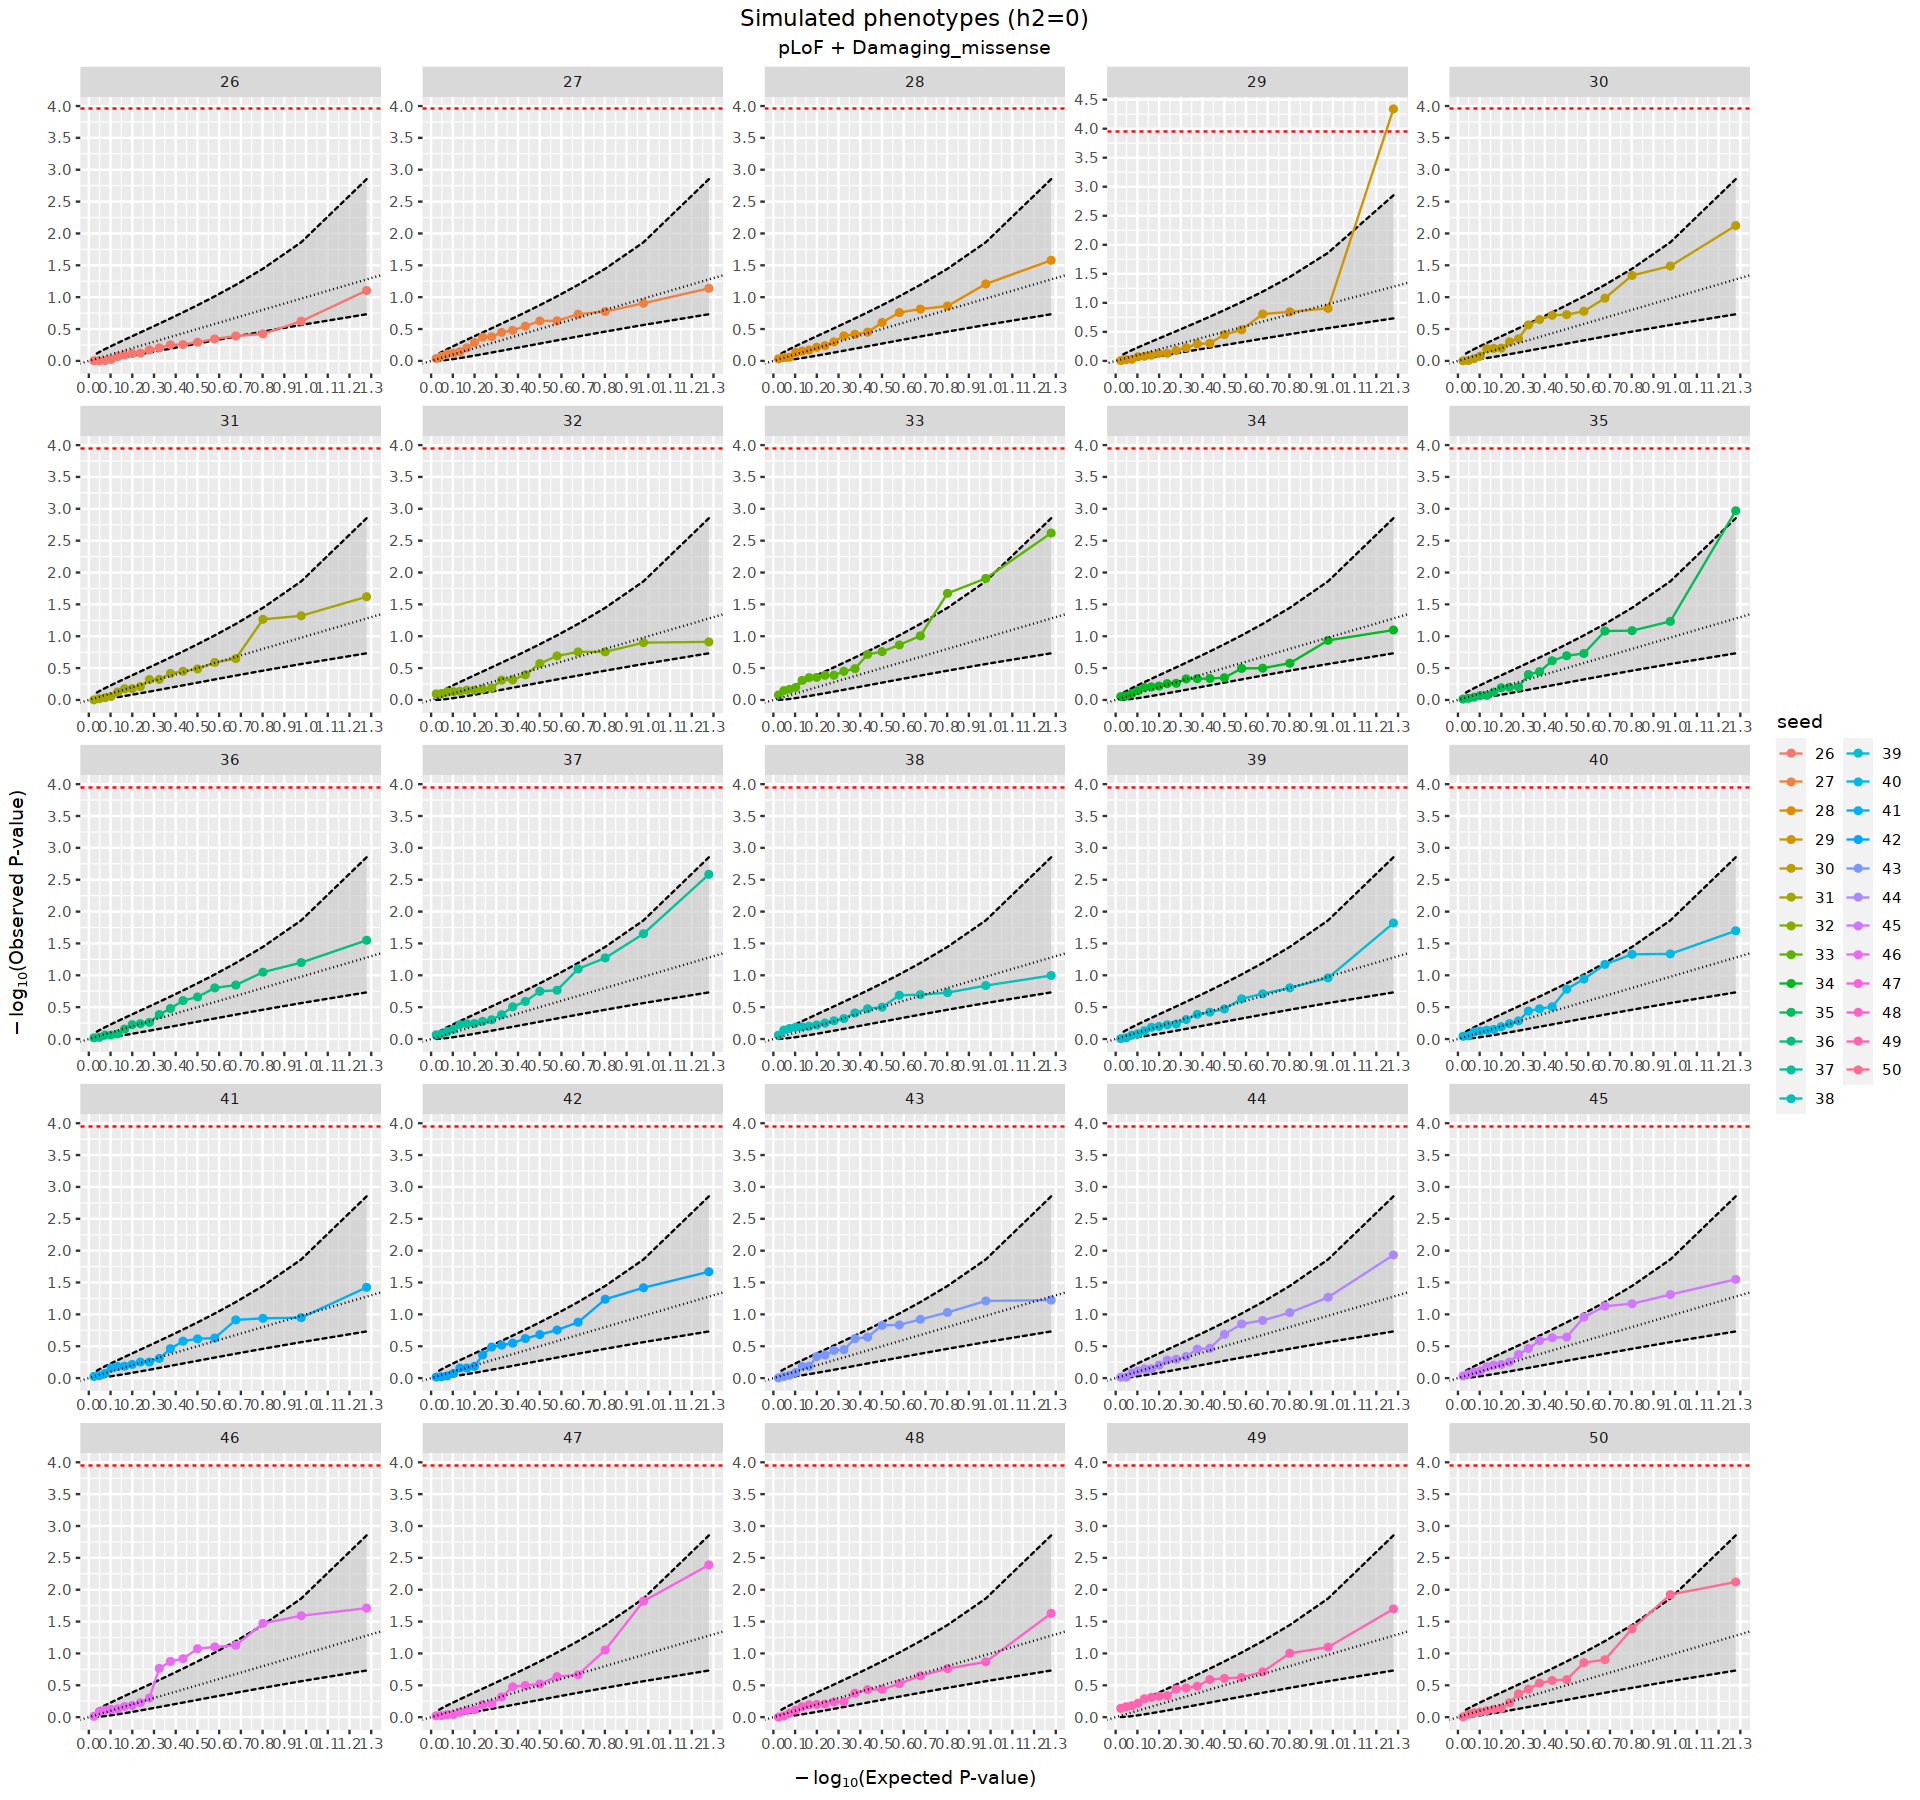

In [48]:
bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))
ggplot(d, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, color = seed)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulated phenotypes (h2=0)", "pLoF + Damaging_missense") +
    facet_wrap(~seed, scales = "free") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

## Simulate CH effect present

In [ ]:
list.files('data/simulation/saige/')

In [ ]:
# Absence of CH effects
#submit_spa 0.00 0.00 0.00 0.00 0.00 0.00 NA NA NA
#submit_spa 0.10 0.00 0.00 0.00 0.00 0.00 NA NA NA
#submit_spa 0.00 0.10 0.00 0.00 0.00 0.00 NA NA NA
#submit_spa 0.10 0.10 0.00 0.00 0.00 0.00 NA NA NA

# simulate CH effects
#submit_spa 0.00 0.00 0.02 0.00 0.00 0.10 NA NA NA
#submit_spa 0.00 0.10 0.02 0.00 0.00 0.10 NA NA NA
#submit_spa 0.00 0.10 0.02 0.00 0.00 0.10 NA NA NA

# simulate effects with thetas
#submit_spa 0.00 0.00 0.00 0.00 0.00 0.10 NA NA 0.01
#submit_spa 0.00 0.00 0.00 0.00 0.00 0.10 NA NA 0.10

In [15]:
#regex <- "ukb_eur_h2_0.0_0.1_pi_0.0_0.1_K_0.1"
regex <- "h2_0.0_0.05_pi_0.0_0.12_K_0.1"
#regex <- "ukb_eur_h2_0.00_0.00_0.00_pi_0.00_0.00_0.00_K0.1_aNA_bNA_tNA_chr21"
fphenos <- list.files('data/simulation/phenotypes/', pattern = "phenos.tsv.gz$", full.names = TRUE)
genes <- list.files('data/simulation/phenotypes/', pattern = "genes.tsv.gz$", full.names = TRUE)
files <- list.files('data/simulation/saige/step2', pattern = ".txt$", full.names = TRUE)
files <- files[grepl(regex, files)]
#fphenos
length(files)

[1] 50

In [16]:
# get genes true positives / knocked out genes
genes <- genes[grepl(regex, genes)]
stopifnot(length(genes) > 0)
k <- do.call(rbind, lapply(genes, function(f){
    g <- fread(f)
    g <- g[g$theta > 0 & g$pKO > 0]
    gtabl <- as.data.frame(table(g$gene_id, g$theta))
    gtabl <- gtabl[gtabl$Freq > 0,]
    if (nrow(gtabl) > 0 ){
        colnames(gtabl)[1:3] <- c('ensembl_gene_id','theta','knockouts')
        seed <- gsub('_genes','',str_extract(f, "[0-9]+_genes"))
        gtabl$seed <- seed
        gtabl$theta <- as.numeric(as.character(gtabl$theta))
        return(gtabl)
    } 
}))
head(k)

,ensembl_gene_id,theta,knockouts,seed
,<fct>,<dbl>,<int>,<chr>
1,ENSG00000142207,0.100210,1,10
4,ENSG00000157578,0.123480,1,10
2,ENSG00000205726,0.049351,1,11
6,ENSG00000285815,0.088489,1,11
7,ENSG00000160233,0.133190,1,11
15,ENSG00000141959,0.094668,5,13


In [5]:
# get actual heritability
#file <- fphenos[1]
#file
#phenos <- fread(file)
#h2 <- round(apply(phenos[,grepl("y_no_noise_ko",colnames(phenos)), with = FALSE], 2, var), 6)
#ggplot(as.data.frame(h2), aes(x=h2)) + geom_histogram(bins = 10)

In [17]:
ribbon_p <- 0.95
d <- do.call(rbind, lapply(files, function(f){
    d <- fread(f)
    d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
    n <- length(d$p.value)
    dt <- data.table(
        ensembl_gene_id = d$MarkerID[order(d$p.value)],
        pvalue.observed = -log10(sort(d$p.value)),
        pvalue.expected = -log10(sort(d$p.value.expt)),
        clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        seed = gsub('cts_','',str_extract(f, "cts_[0-9]+")),
        parameters = str_extract(f, "h2_.+chr21")
        
    )
    return(dt)
}))


In [18]:
final <- merge(d, k, by = c("ensembl_gene_id", "seed"), all.x = TRUE)
final$seed <- factor(final$seed, levels = 1:100)
bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))

In [9]:
# confusion matrix
true_positives <- sum(final$pvalue.observed[!is.na(final$knockouts)] >= -log10(bonf))
false_positives <- sum(final$pvalue.observed[!is.na(final$knockouts)] < -log10(bonf))
true_negatives <- sum(final$pvalue.observed[is.na(final$knockouts)] < -log10(bonf))
false_negatives <- sum(final$pvalue.observed[is.na(final$knockouts)] >= -log10(bonf))
confusion <- matrix(c(true_positives, false_positives, false_negatives, true_negatives), nrow = 2)
rownames(confusion) <- c("Significant", "Not significant")
colnames(confusion) <- c("CH", "not CH")
confusion

,CH,not CH
Significant,23,0
Not significant,6,521


In [10]:
seed_table <- as.data.frame(table(final$seed, final$knockouts))
seed_w_ko <- unique(seed_table$Var1[seed_table$Freq > 0])
seed_wo_ko <- unique(seed_table$Var1[!seed_table$Var1 %in% seed_w_ko])

Warning message:
"Removed 235 rows containing missing values (geom_text_repel)."


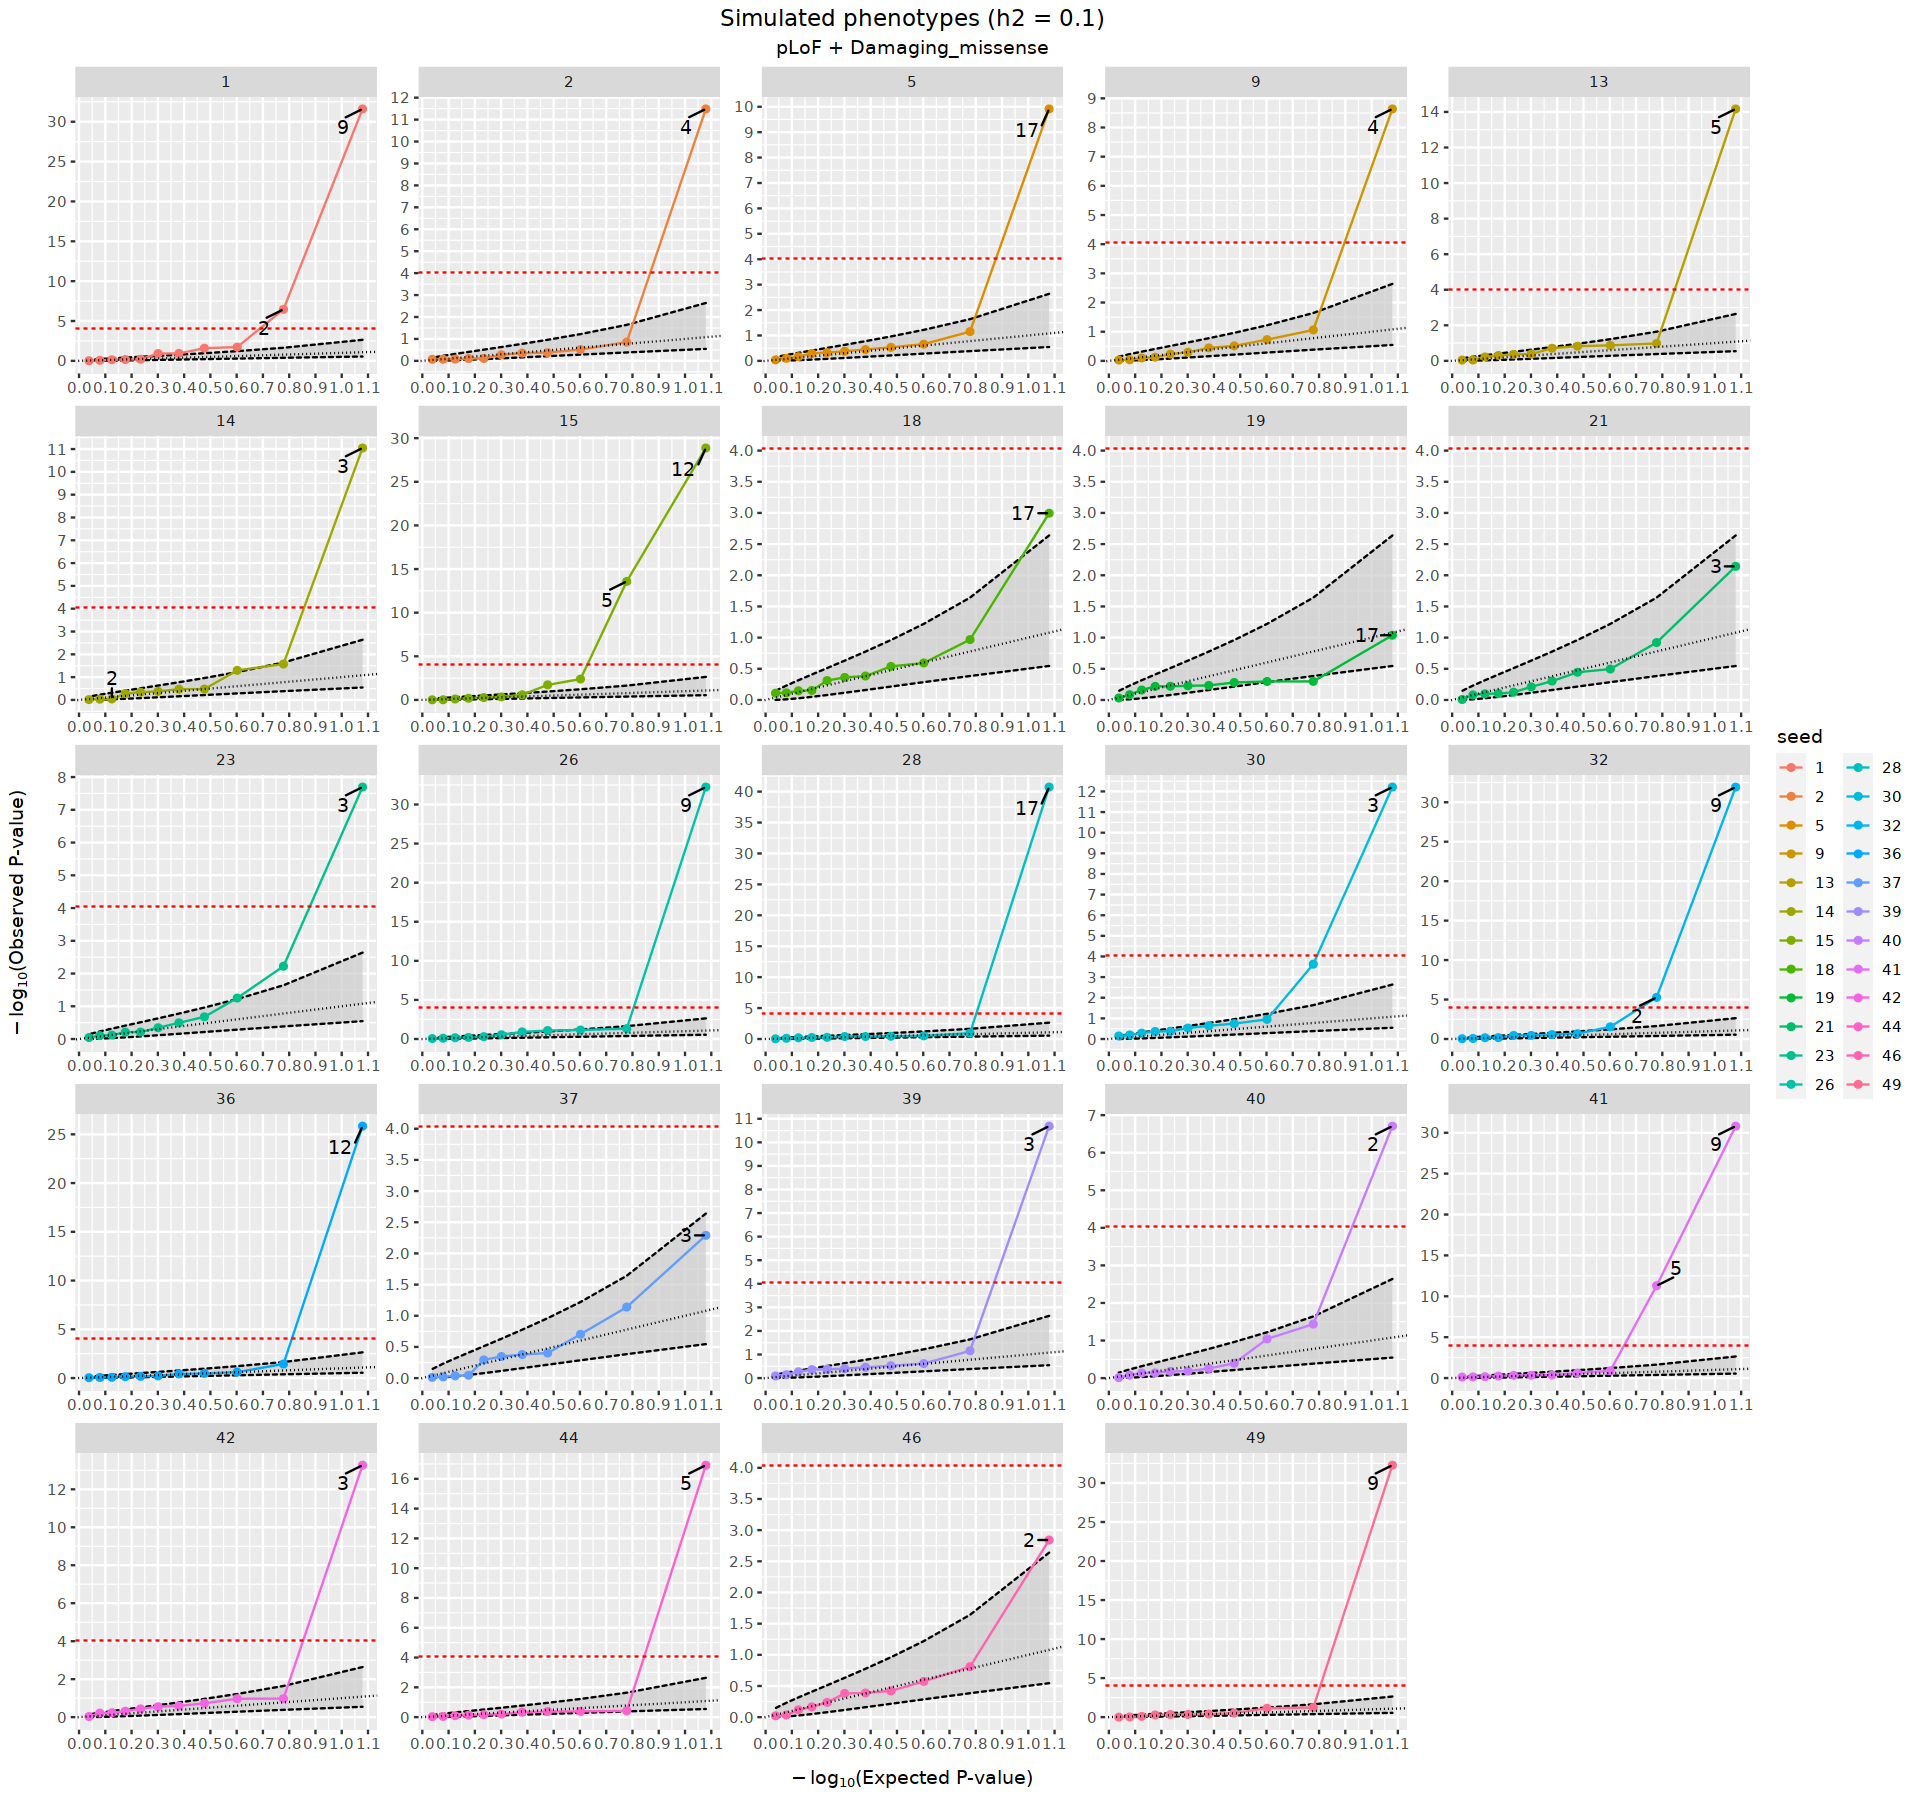

In [23]:
options(repr.plot.width=16, repr.plot.height=15)

ggplot(final[final$seed %in% seed_w_ko], 
       aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, color = seed, label = knockouts)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_text_repel(
        color = 'black', 
        min.segment.length = 0.2, 
        box.padding = 0.5,
    ) + 
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    facet_wrap(~seed, scales = "free") + 
    ggtitle("Simulated phenotypes (h2 = 0.1)", "pLoF + Damaging_missense") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

Warning message:
"Removed 235 rows containing missing values (geom_text_repel)."


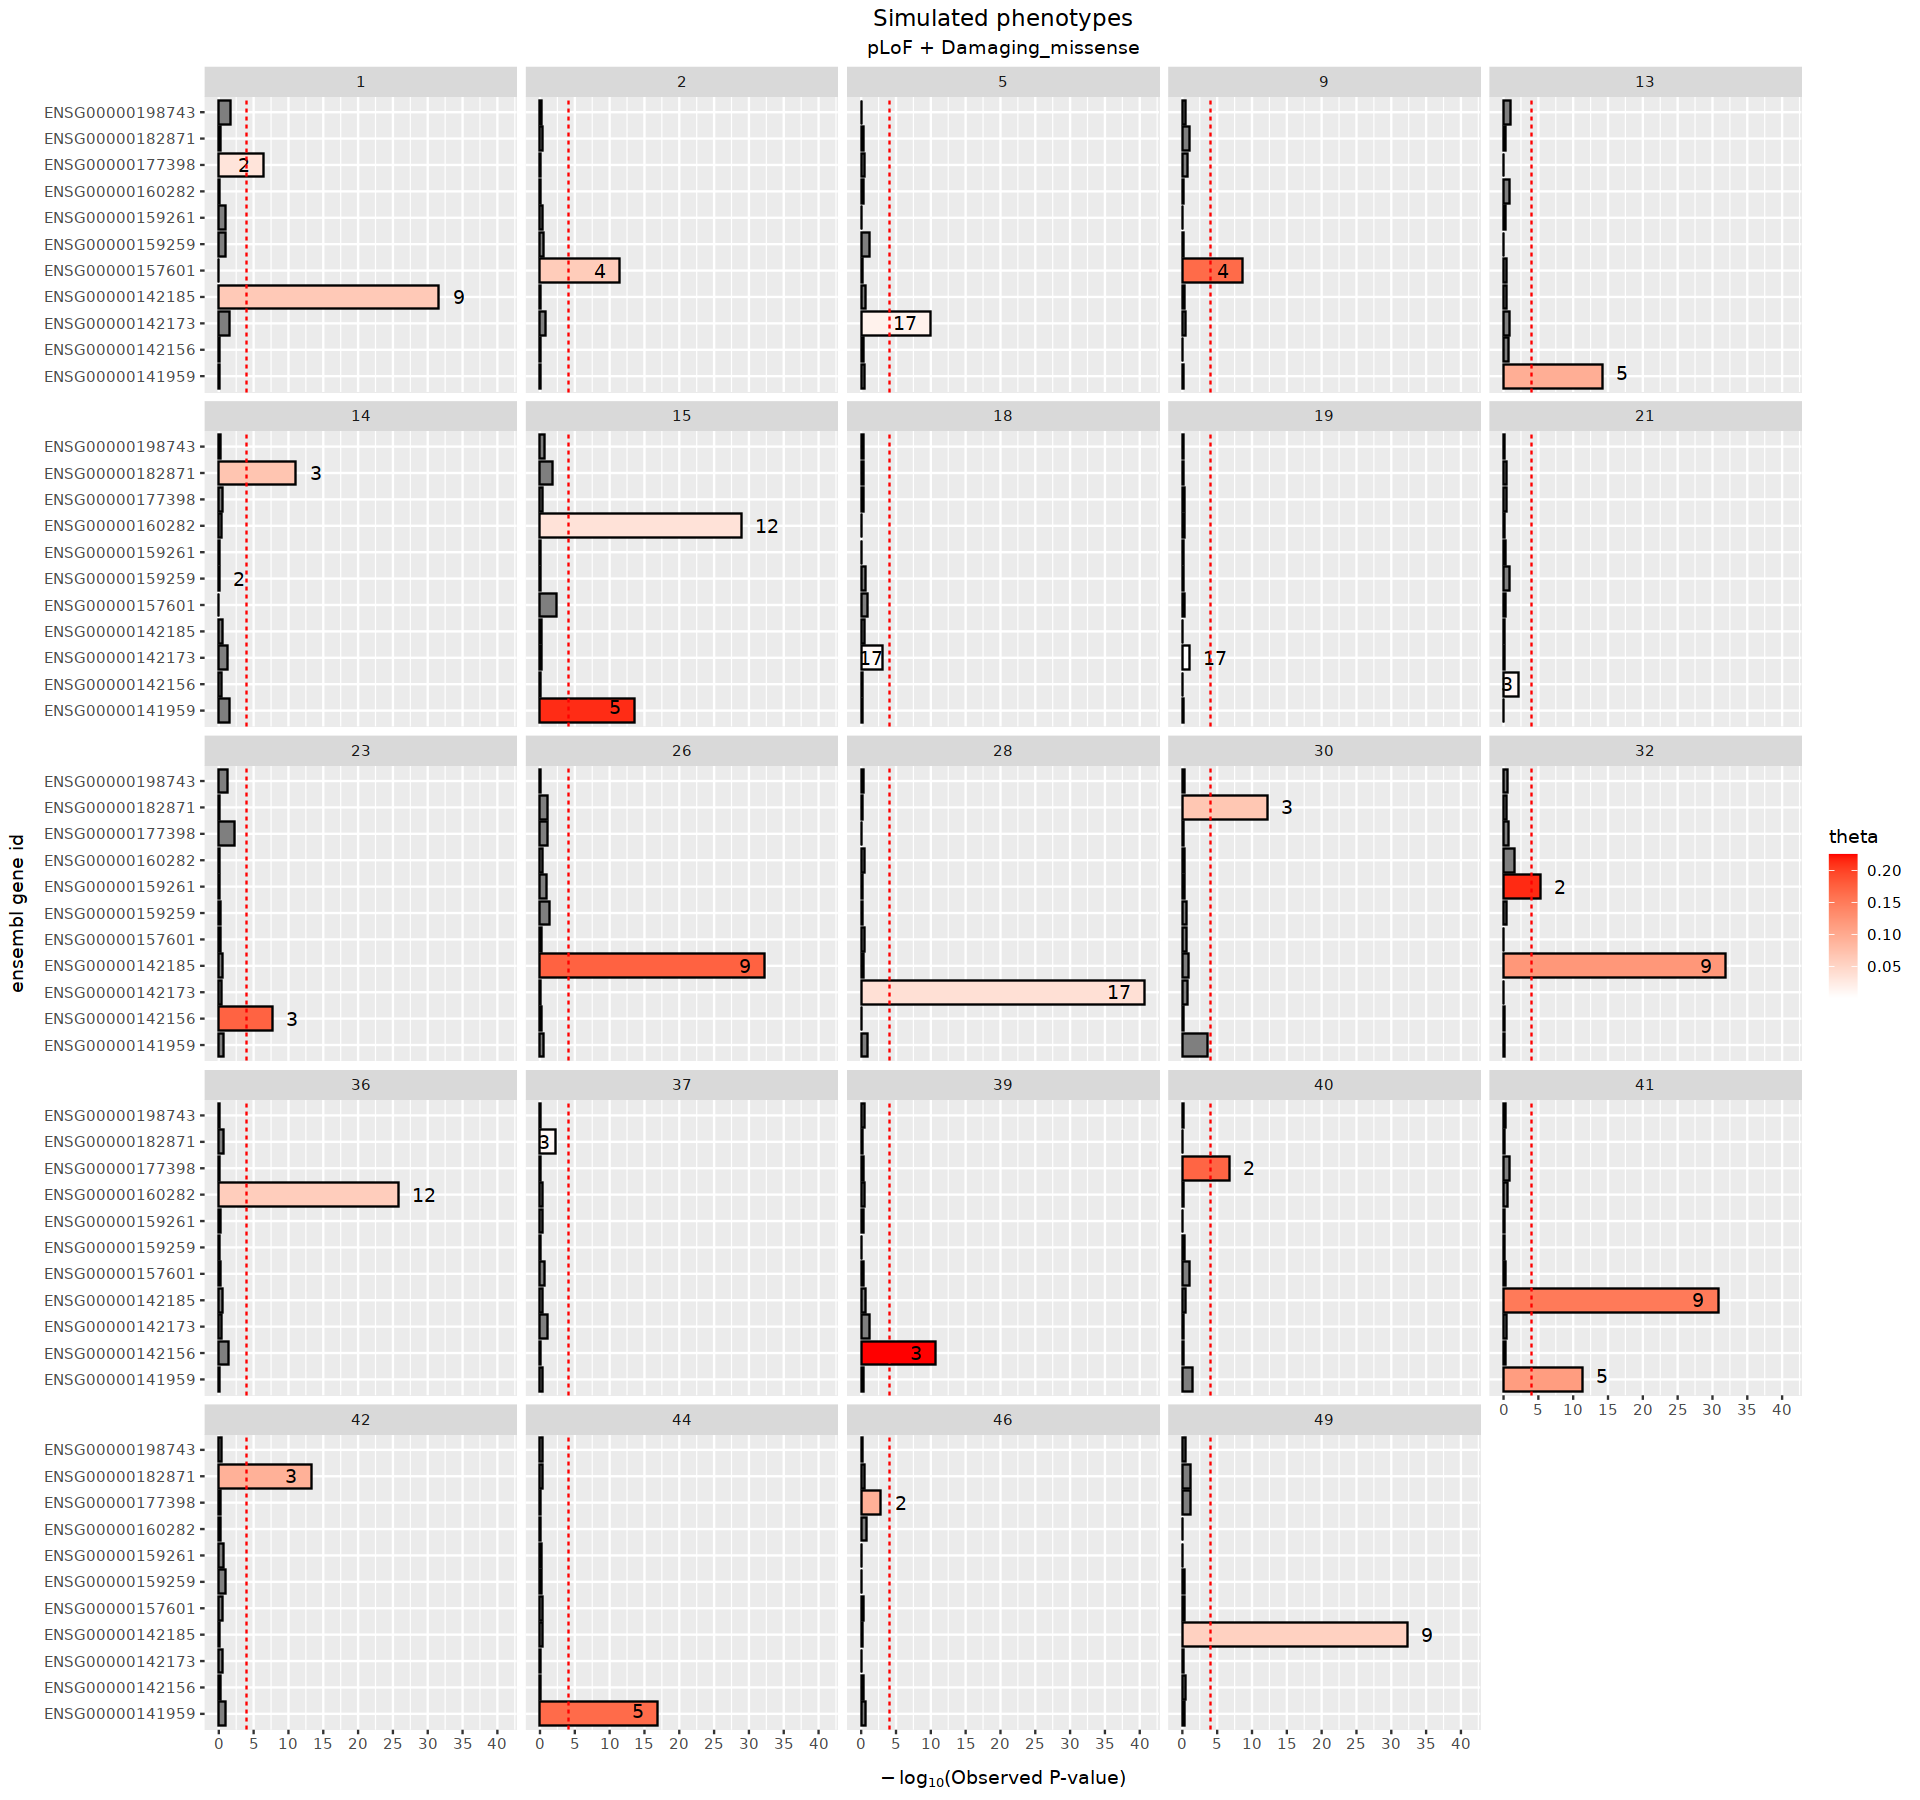

In [24]:
#final$knockouts[is.na(final$knockouts)] <- 0
ggplot(final[final$seed %in% seed_w_ko], 
       aes(y=ensembl_gene_id, x=pvalue.observed, fill = theta, label = knockouts)) +
    geom_bar(stat="identity", color = 'black') + 
    scale_fill_gradient(low = "white", high = 'red') +
    geom_text_repel(
            color = 'black', 
            min.segment.length = 0.4, 
            box.padding = 0.5,
            direction = "x"
            
    ) + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Observed P-value)' ))) +
    ylab("ensembl gene id") +
    geom_vline(xintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    facet_wrap(~seed) + #, scales = "free_x") + 
    ggtitle("Simulated phenotypes", "pLoF + Damaging_missense") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

In [85]:
# let's investigate plot iteration 4 (two genes are significant)
dt <- final[final$iteration == 1,]
dt <- tail(dt[order(dt$pvalue.observed),], n = 2)
dt

ensembl_gene_id,iteration,pvalue.observed,pvalue.expected,clower,cupper,parameters,knockouts
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
ENSG00000183486,1,4.227291,1.146128,2.040955,0.7219198,h2_0.0_0.1_pi_0.0_0.1_K_0.1_chr21,NA
ENSG00000156284,1,8.096363,1.447158,3.028141,0.8937994,h2_0.0_0.1_pi_0.0_0.1_K_0.1_chr21,NA


In [86]:
g_all <- fread('data/simulation/phenotypes//ukb_eur_h2_0.0_0.09_pi_0.0_0.1_K_0.1_chr21_1_genes.tsv.gz')

In [83]:
#g_all[g_all$theta != 0,]

In [87]:
#g_all[g_all$y_no_noise != -0.0012054, ]

In [88]:
table(g_all$y_no_noise_ko)


-0.0017644     5.9551     6.8716     11.912     13.745     171.48 
   6545374         74         37         37        296         37 

In [89]:
g_all <- fread('data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.1_K_0.1_chr21_1_genes.tsv.gz')
g <- g_all[g_all$gene_id %in% dt$ensembl_gene_id]

In [43]:
#var(g_all$y_no_noise_ko)
#ggplot(g, aes(x=y_no_noise_ko)) +
#    geom_histogram()

[1] 0.07855404

In [90]:
# ENSG00000142185 <--- causal
# ENSG00000160282 <--- NOT causal
g[g$pKO > 0,]

gene_id,theta,s,y_no_noise_ko,pKO,knockout
<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>
ENSG00000156284,0,2754583,37.930,1.0,Compound heterozygote
ENSG00000156284,0,4037043,18.965,0.5,Possible Compound heterozygote
ENSG00000183486,0,4291078,-36.778,1.0,Compound heterozygote


In [97]:
# random individual from above
g_all[g_all$s %in% 2754583,]

gene_id,theta,s,y_no_noise_ko,pKO,knockout
<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>
ENSG00000141956,0.00000,2754583,37.93,0,NA
ENSG00000141959,0.00000,2754583,37.93,0,NA
ENSG00000142156,0.00000,2754583,37.93,0,NA
ENSG00000142173,0.00000,2754583,37.93,0,NA
ENSG00000142185,0.00000,2754583,37.93,0,NA
ENSG00000142192,0.00000,2754583,37.93,0,NA
ENSG00000142197,0.00000,2754583,37.93,0,NA
ENSG00000142207,0.00000,2754583,37.93,0,NA
ENSG00000155313,0.00000,2754583,37.93,0,NA


In [92]:
#g_all[g_all$s %in% 2435619,]

In [93]:
# so these two both have quite a few knockouts
table(g$gene_id, g$pKO)

                 
                       0    0.5      1
  ENSG00000156284 176913      1      1
  ENSG00000183486 176914      0      1

In [94]:
samples <- g$s[g$pKO>0]

In [95]:
M <- do.call(rbind, lapply(samples, function(s){
    bool <- g$s %in% s
    d <- g[bool, ]
    return(d)
}))
head(M)

gene_id,theta,s,y_no_noise_ko,pKO,knockout
<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>
ENSG00000156284,0,2754583,37.930,1.0,Compound heterozygote
ENSG00000183486,0,2754583,37.930,0.0,NA
ENSG00000156284,0,4037043,18.965,0.5,Possible Compound heterozygote
ENSG00000183486,0,4037043,18.965,0.0,NA
ENSG00000156284,0,4291078,-36.778,0.0,NA
ENSG00000183486,0,4291078,-36.778,1.0,Compound heterozygote


In [28]:
2+2

[1] 4

In [18]:
g <- fread('data/simulation/phenotypes//ukb_eur_h2_0.0_0.1_pi_0.0_0.1_K_0.1_chr21_4_genes.tsv.gz')
table(g$y_no_noise_ko)


   -91.578    -16.132    -9.4787    -8.0658 0.00078472     8.6926     17.384 
        37        407         37         37    6545004         37        296 

In [19]:
g[g$theta,]

gene_id,theta,s,y_no_noise_ko,pKO,knockout
<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>


In [ ]:
# manuel simulation in R


In [31]:
files <- list.files('data/simulation/phenotypes/', full.names = TRUE, pattern = "genes.tsv.gz")

In [49]:
f <- files[2]
d <- fread(f)

In [50]:
f

[1] "data/simulation/phenotypes//ukb_eur_h2_0.0_0.09_pi_0.0_0.1_K_0.1_chr21_1_genes.tsv.gz"

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



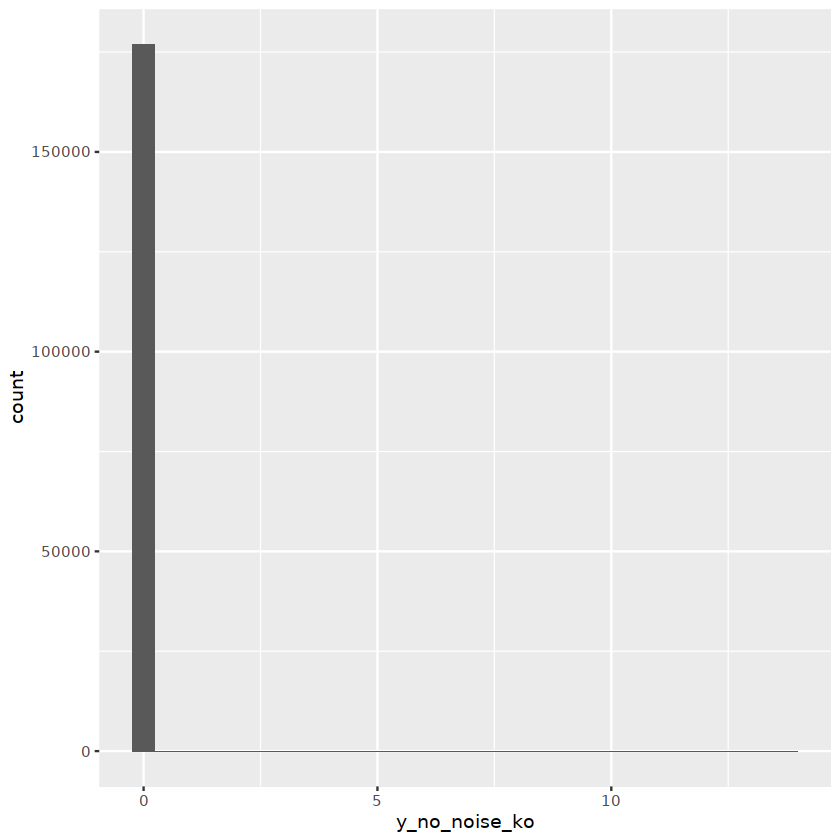

In [51]:
ggplot(d, aes(x=y_no_noise_ko)) +
    geom_histogram()

In [52]:
# how many individuals have the median no_noise_ko
avg <- median(d$y_no_noise_ko)
sum(d$y_no_noise_ko == avg)/nrow(d)

[1] 0.9999491

In [53]:
# how many samples are compound hets and have a non-zero theta
sch <- unique(d$s[d$theta != 0 & d$pKO > 0 ])
sch

[1] 1236963 1739303 1797285 2613995 2720859 3576524 3812769 4054148 5513617

In [54]:
unique(d$pKO)

[1] 0.0 1.0 0.5

In [55]:
lstch <- lapply(sch, function(eid){
    d[d$s %in% eid,]
})

In [56]:
dt <- lstch[[1]]
print(sum(dt$norm_pKO * dt$theta))

[1] 13.74662


In [57]:
# how many individuals have a deviation from the median
s = unique(d$s[d$y_no_noise_ko != avg])
s

[1] 1236963 1739303 1797285 2613995 2720859 3576524 3812769 4054148 5513617

In [58]:
# are these all compound het/homs in some way?
lst <- lapply(s, function(eid){
    d[d$s %in% eid,]
})

In [64]:
# this indiviual has a large 
dt <- lst[[6]]
dt 
sum(dt$y_theta_norm_pKO)

gene_id,theta,s,y_no_noise_ko,y,pKO,norm_pKO,knockout
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000142185,0.093872,3576524,13.746,13.551,1,146.44,Compound heterozygote


[1] 0

In [48]:
sum(dt$norm_pKO * dt$theta)

[1] 76.32775

In [166]:
sum(dt$pKO * dt$theta)

[1] 0

In [70]:
nrow(dt)

[1] 37

In [71]:
dt$norm_pKO * dt$theta

[1]  0.0000000000  0.0000000000  0.0000000000  0.0000000000  0.0000000000
 [6]  0.0000000000  0.0000000000 -0.0003501344  0.0000000000  0.0000000000
[11]  0.0000000000  0.0000000000  0.0000000000 -0.0004314449  0.0000000000
[16]  0.0000000000  0.0000000000  0.0000000000  0.0000000000  0.0000000000
[21]  0.0000000000  0.0000000000  0.0004963713  0.0000000000  0.0000000000
[26]  0.0000000000  0.0000000000  0.0000000000  0.0000000000  0.0000000000
[31]  0.0000000000  0.0000000000  0.0000000000  0.0000000000  0.0000000000
[36]  0.0000000000  0.0000000000

In [73]:
dt$theta

[1]  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
 [8]  0.147270  0.000000  0.000000  0.000000  0.000000  0.000000  0.181470
[15]  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
[22]  0.000000 -0.060891  0.000000  0.000000  0.000000  0.000000  0.000000
[29]  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
[36]  0.000000  0.000000

In [74]:
d[d$s %in% "1604172"]

gene_id,theta,s,y_no_noise_ko,y,pKO,norm_pKO,knockout
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000141956,0.000000,1604172,-43.45,-45.295,0.0,-0.1461200,NA
ENSG00000141959,0.000000,1604172,-43.45,-45.295,0.0,-0.0050833,NA
ENSG00000142156,0.000000,1604172,-43.45,-45.295,0.0,-0.0039625,NA
ENSG00000142173,0.000000,1604172,-43.45,-45.295,0.0,-0.0097319,NA
ENSG00000142185,0.000000,1604172,-43.45,-45.295,0.0,-0.0070359,NA
ENSG00000142192,0.000000,1604172,-43.45,-45.295,0.0,-0.0023775,NA
ENSG00000142197,0.000000,1604172,-43.45,-45.295,0.0,-0.0023775,NA
ENSG00000142207,0.147270,1604172,-43.45,-45.295,0.0,-0.0023775,NA
ENSG00000155313,0.000000,1604172,-43.45,-45.295,0.0,-0.0023775,NA


## Simulation of compound het effects with constant theta

In [49]:
files <- list.files('data/simulation/saige/step2', pattern = ".txt$", full.names = TRUE)

In [53]:
#files

In [59]:
regex <- "ukb_eur_h2_0.00_0.00_0.00_pi_0.00_0.00_0.10_K0.1_aNA_bNA_t0.01"
fphenos <- list.files('data/simulation/phenotypes/', pattern = "phenos.tsv.gz$", full.names = TRUE)
genes <- list.files('data/simulation/phenotypes/', pattern = "genes.tsv.gz$", full.names = TRUE)
files <- list.files('data/simulation/saige/step2', pattern = ".txt$", full.names = TRUE)
files <- files[grepl(regex, files)]
#fphenos
length(files)

[1] 43

In [60]:
# get genes true positives / knocked out genes
genes <- genes[grepl(regex, genes)]
stopifnot(length(genes) > 0)
k <- do.call(rbind, lapply(genes, function(f){
    g <- fread(f)
    g <- g[g$theta > 0 & g$pKO > 0]
    gtabl <- as.data.frame(table(g$gene_id, g$theta))
    gtabl <- gtabl[gtabl$Freq > 0,]
    if (nrow(gtabl) > 0 ){
        colnames(gtabl)[1:3] <- c('ensembl_gene_id','theta','knockouts')
        seed <- gsub('_genes','',str_extract(f, "[0-9]+_genes"))
        gtabl$seed <- seed
        gtabl$theta <- as.numeric(as.character(gtabl$theta))
        return(gtabl)
    } 
}))
head(k)

,ensembl_gene_id,theta,knockouts,seed
,<fct>,<dbl>,<int>,<chr>
1,ENSG00000142207,0.01,1,10
2,ENSG00000157578,0.01,1,10
3,ENSG00000160282,0.01,12,10
4,ENSG00000142207,0.01,1,11
5,ENSG00000156284,0.01,2,11
6,ENSG00000160233,0.01,1,11


In [61]:
ribbon_p <- 0.95
d <- do.call(rbind, lapply(files, function(f){
    d <- fread(f)
    d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
    n <- length(d$p.value)
    dt <- data.table(
        ensembl_gene_id = d$MarkerID[order(d$p.value)],
        pvalue.observed = -log10(sort(d$p.value)),
        pvalue.expected = -log10(sort(d$p.value.expt)),
        clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        seed = gsub('cts_','',str_extract(f, "cts_[0-9]+")),
        parameters = str_extract(f, "h2_.+chr21")
        
    )
    return(dt)
}))


In [62]:
final <- merge(d, k, by = c("ensembl_gene_id", "seed"), all.x = TRUE)
final$seed <- factor(final$seed, levels = 1:100)
bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?

geom_path: Each group consists of only one observation. Do you need to adjust
the group aesthetic?



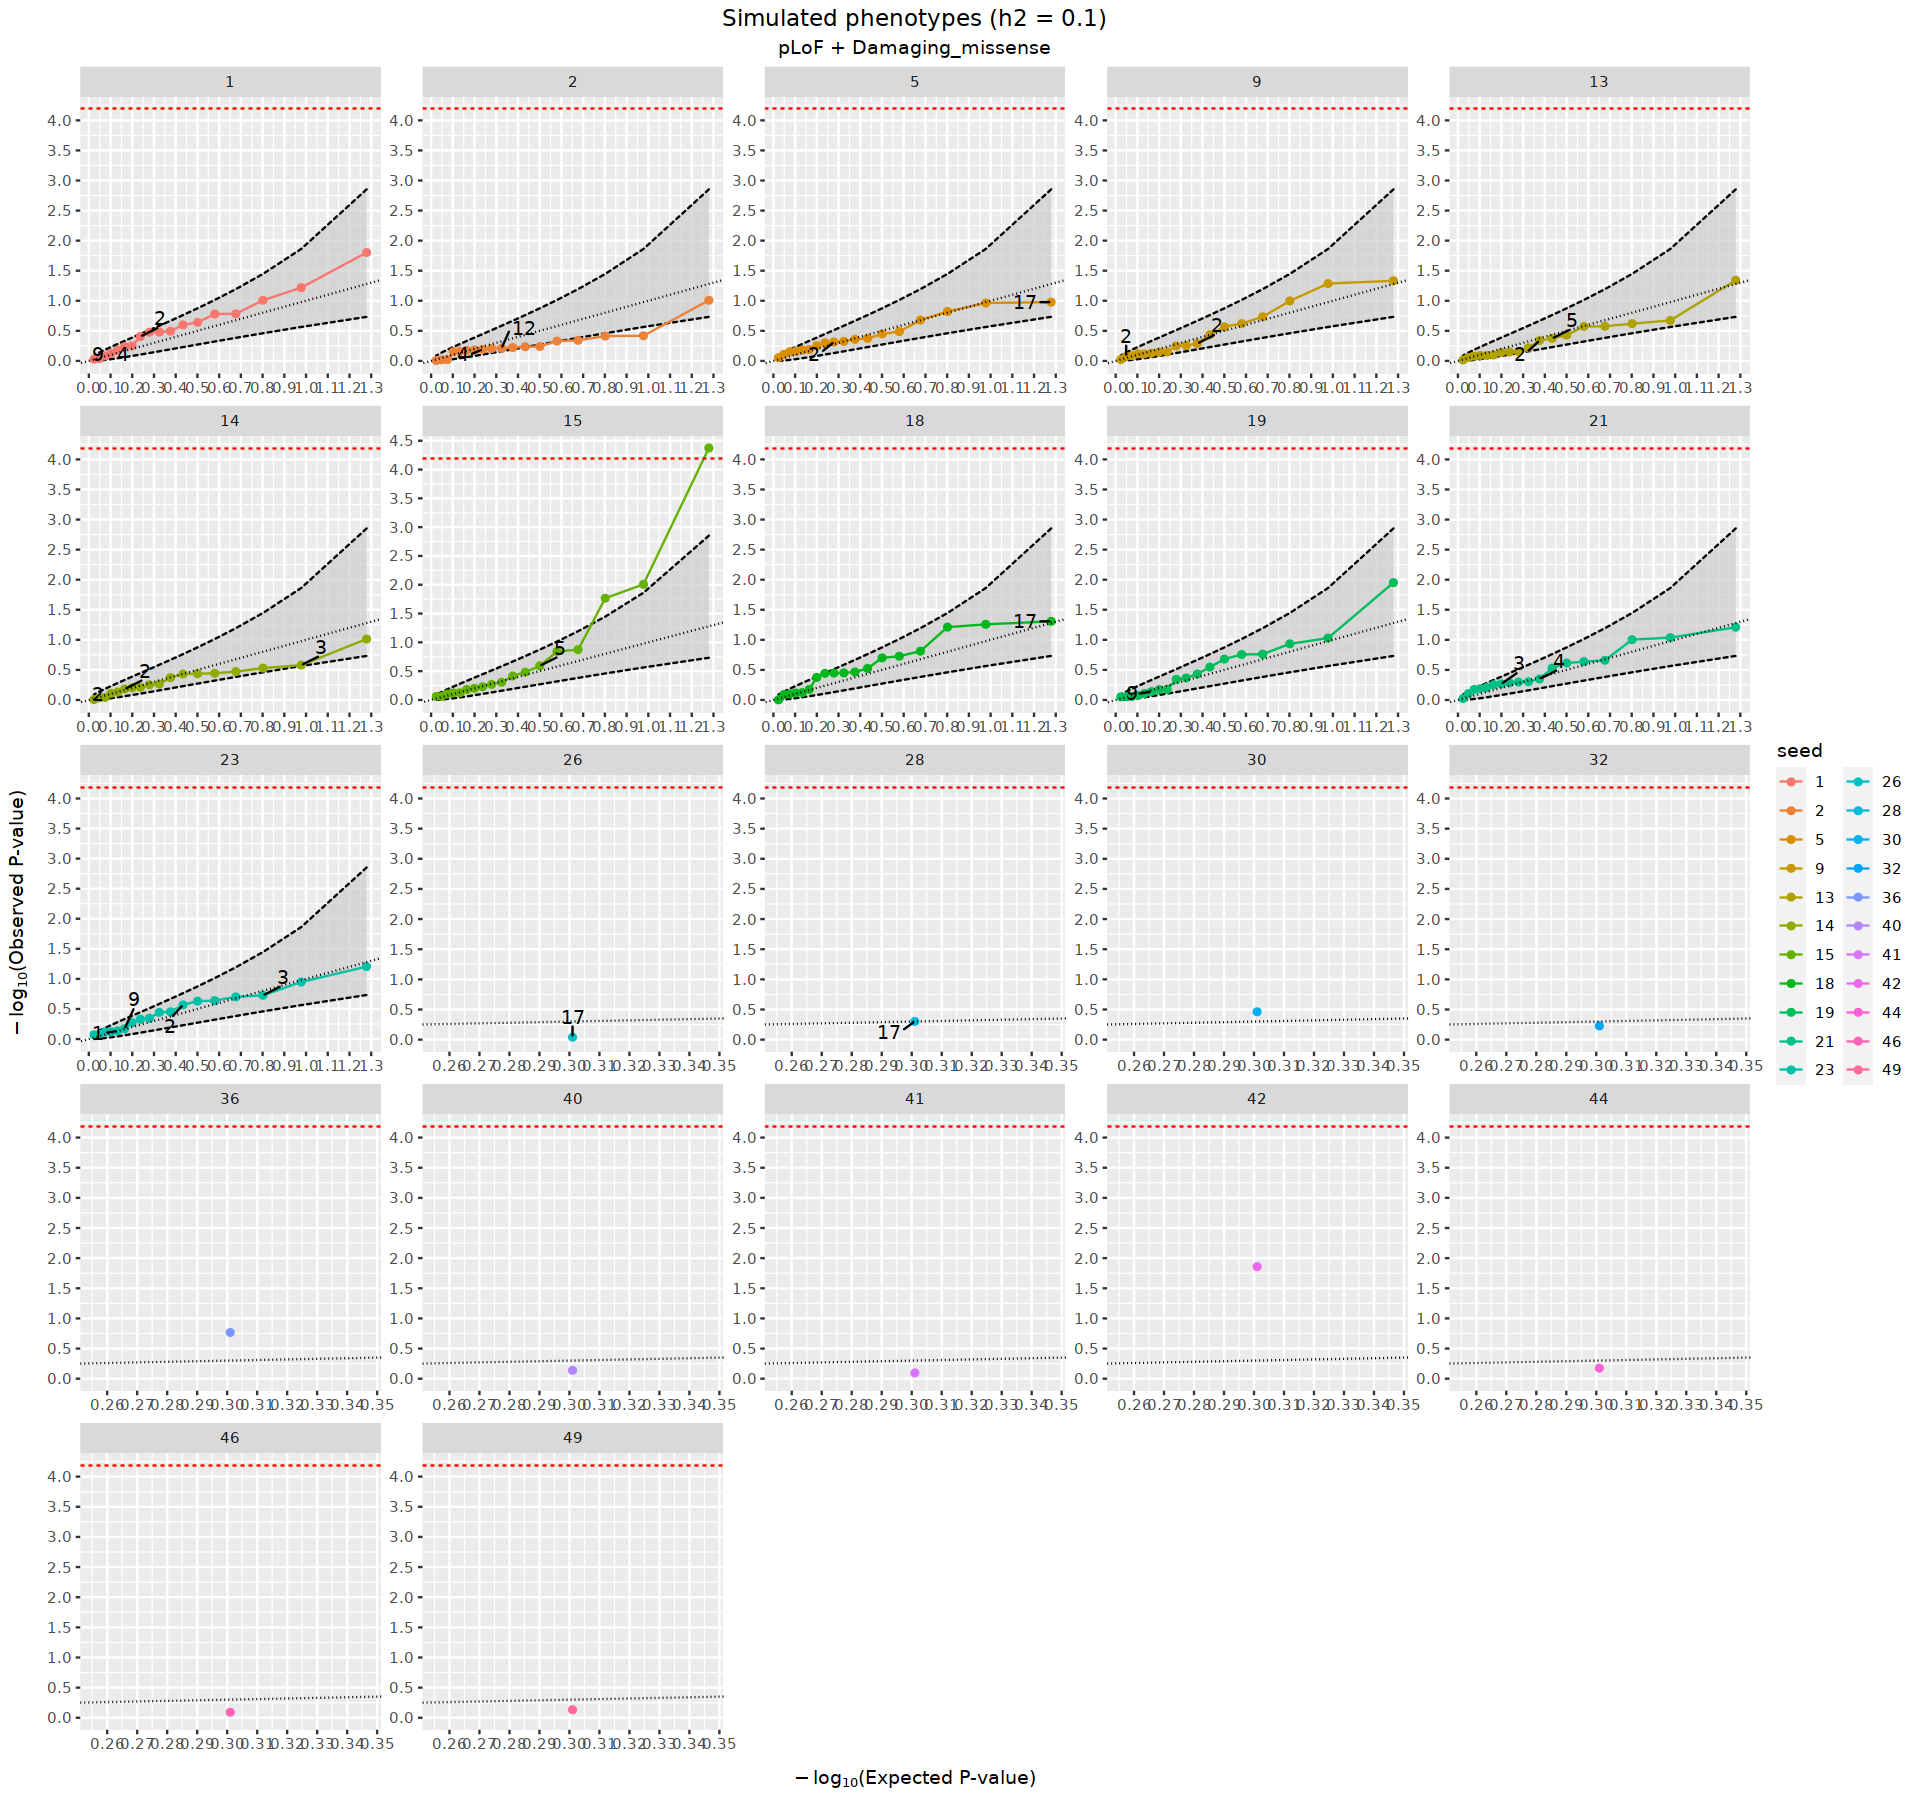

In [63]:
options(repr.plot.width=16, repr.plot.height=15)

ggplot(final[final$seed %in% seed_w_ko], 
       aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, color = seed, label = knockouts)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_text_repel(
        color = 'black', 
        min.segment.length = 0.2, 
        box.padding = 0.5,
    ) + 
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    facet_wrap(~seed, scales = "free") + 
    ggtitle("Simulated phenotypes (h2 = 0.1)", "pLoF + Damaging_missense") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

Warning message:
"Removed 184 rows containing missing values (geom_text_repel)."


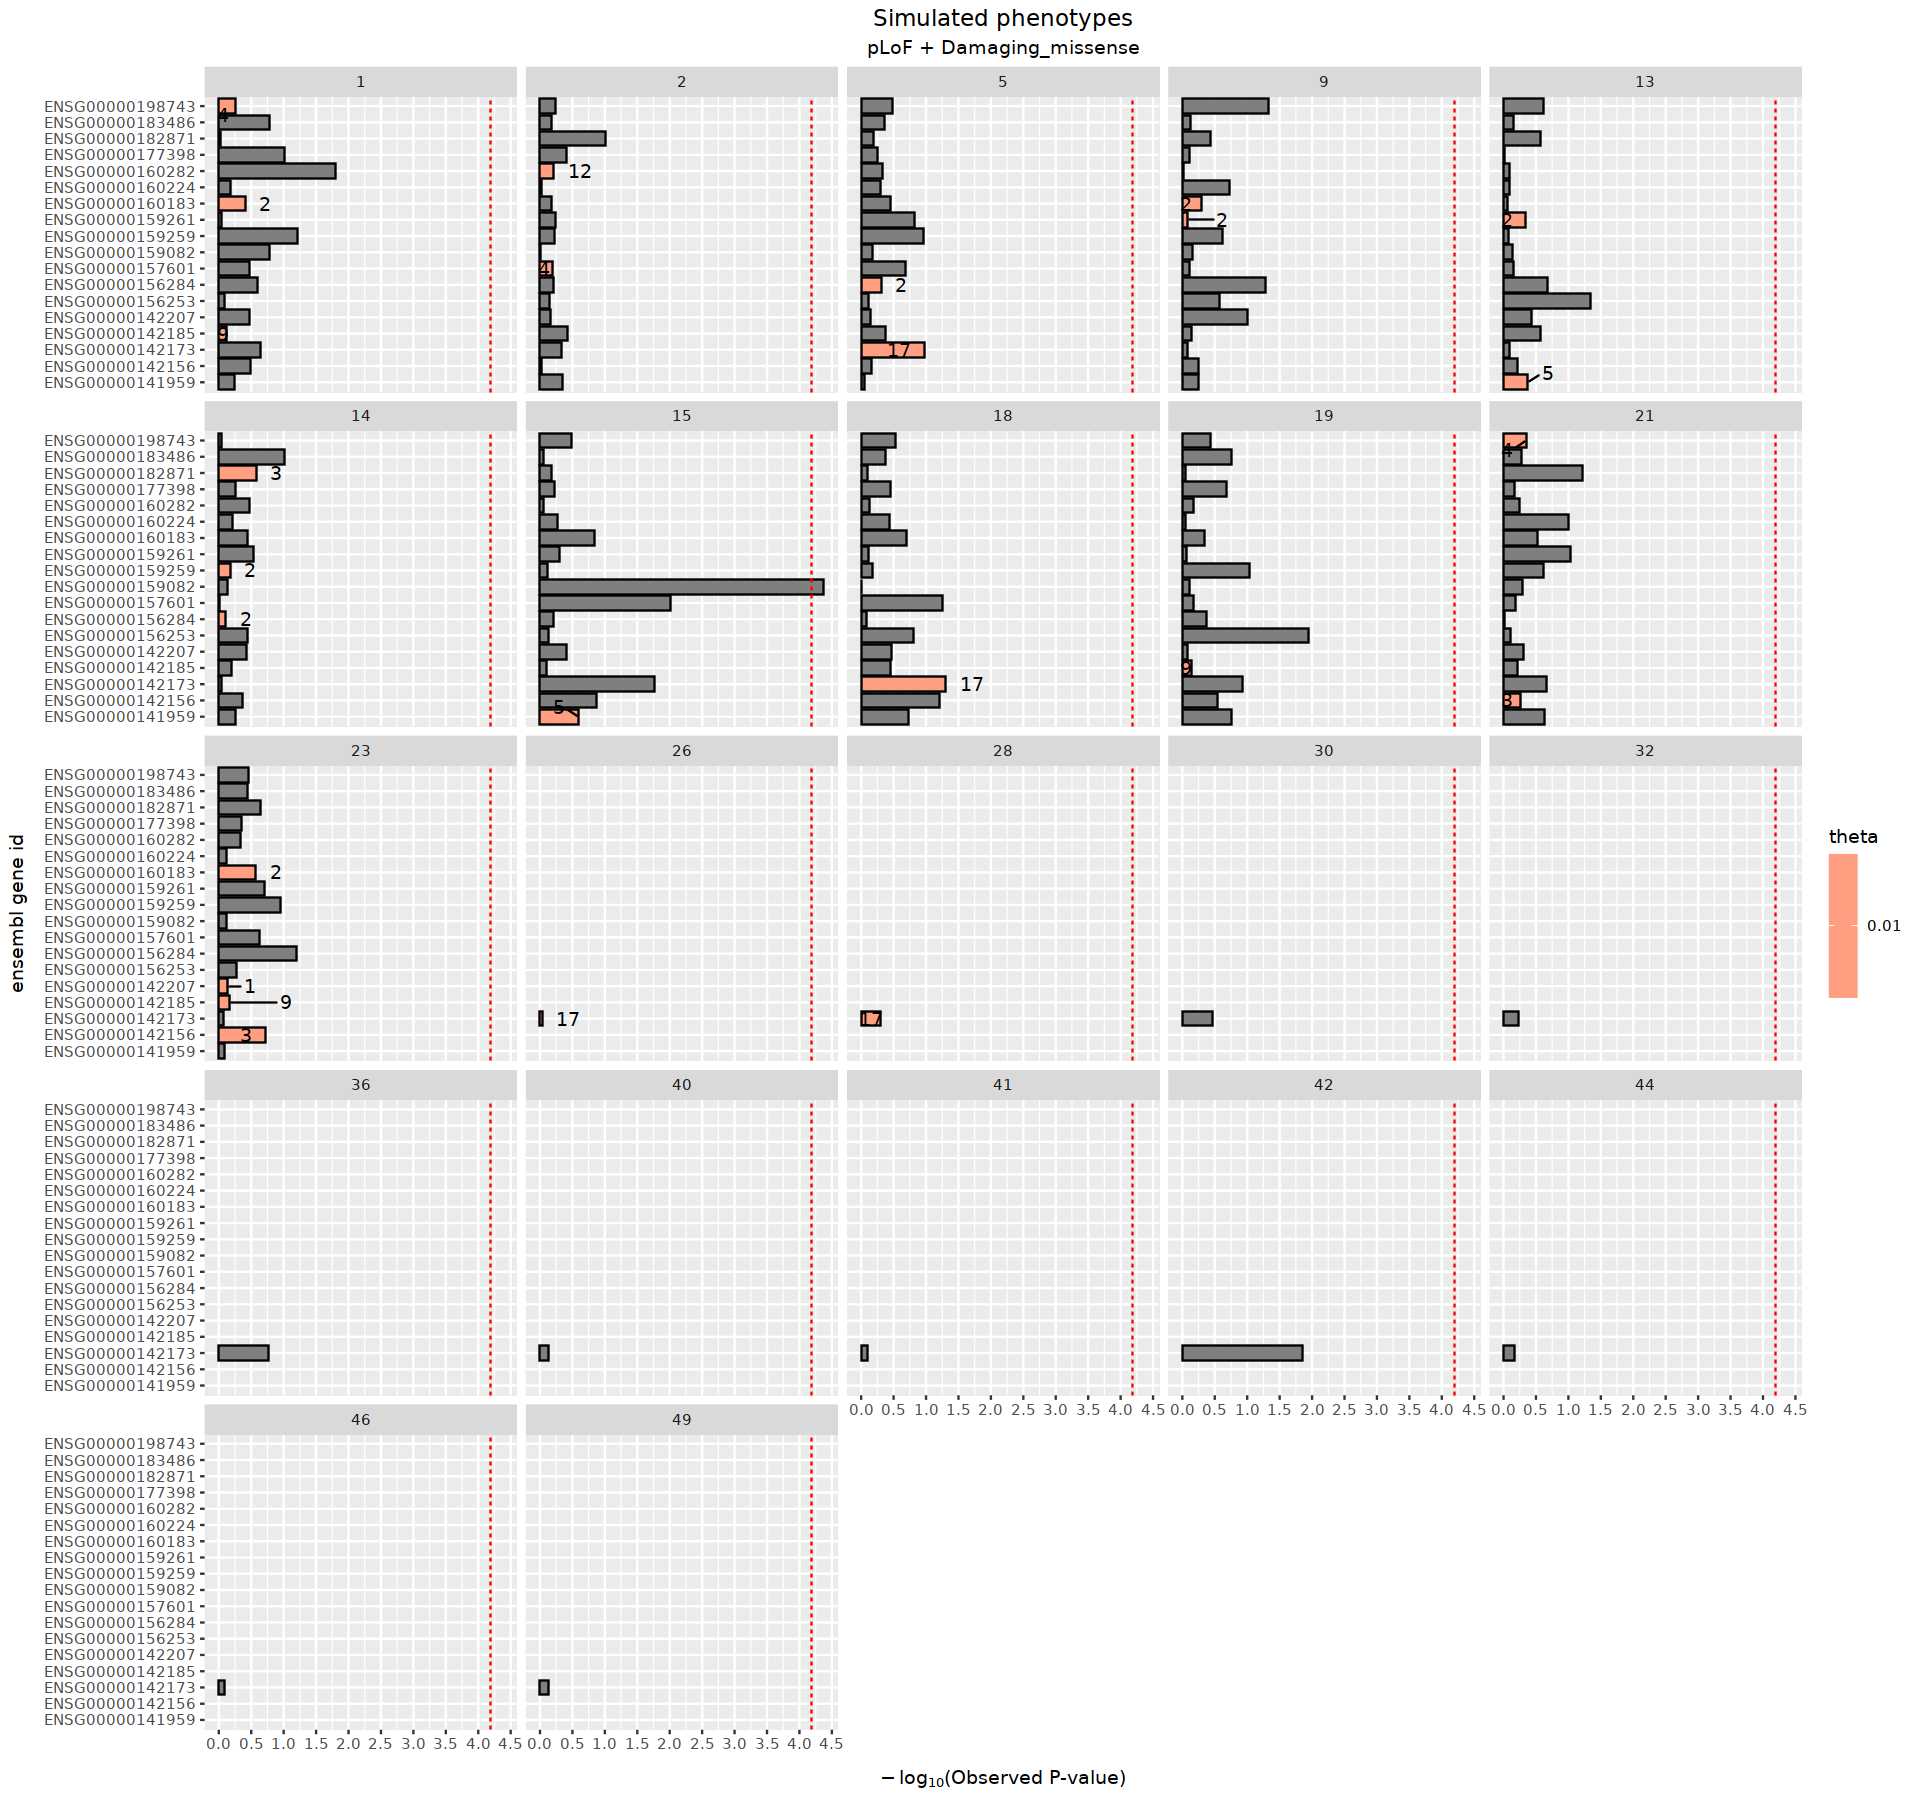

In [64]:
#final$knockouts[is.na(final$knockouts)] <- 0
ggplot(final[final$seed %in% seed_w_ko], 
       aes(y=ensembl_gene_id, x=pvalue.observed, fill = theta, label = knockouts)) +
    geom_bar(stat="identity", color = 'black') + 
    scale_fill_gradient(low = "white", high = 'red') +
    geom_text_repel(
            color = 'black', 
            min.segment.length = 0.4, 
            box.padding = 0.5,
            direction = "x"
            
    ) + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Observed P-value)' ))) +
    ylab("ensembl gene id") +
    geom_vline(xintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    facet_wrap(~seed) + #, scales = "free_x") + 
    ggtitle("Simulated phenotypes", "pLoF + Damaging_missense") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))